# 420 — Pool power & qualify contacts

Reads the windows from `410` and pools ERSP power inside each, then asks — per contact — whether
the response is **significant in the clustering sense, restricted to the window**.

**Pooling** = a **time-weighted average** of the contact's power over the window (boxcar = equal
weight inside the box; Gaussian = centre-weighted). Run for **two feature sets**, identically:
- **`hg`** — the single 70–150 Hz high-gamma line (the canonical iEEG task-response marker).
- **`bands15`** — the 15 frequency bands **separately**, on the native 300-bin time axis.

**Qualification** = clustering's high-activity gate (`prop(>2.2σ) ≥ 0.02` **OR**
`prop(<−3.0σ) ≥ 0.04`), computed **only over the window's time columns** — so it is *comparable*
to clustering but window-restricted. **Both signs are kept** (a contact can qualify as `+`
activation or `−` suppression). Gaussian gate support = centre ± 2σ (95% mass).

> ⚠️ *Comparable, not identical:* a contact that passes whole-ERSP clustering gating can fail a
> narrow window — that asymmetry is the confirmatory test, by design.

Optional secondary robustness: a per-contact **circular-time-shift null p** (`N_PERM > 0`).


In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_pool as P

INPUT_DIR = Path(r'\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

print('INPUT_DIR :', INPUT_DIR, '| exists:', INPUT_DIR.exists())
print('OUTPUTS   :', P.OUTPUTS_ROOT)
print('COORDS    :', P.COORDS_DIR, '| exists:', P.COORDS_DIR.exists())
print('conditions:', P.CONDITIONS, '| zones:', P.DEFAULT_ZONES)
print('feature sets:', P.FEATURE_SETS, '| window shapes:', P.WINDOW_SHAPES)


INPUT_DIR : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY | exists: True
OUTPUTS   : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling
COORDS    : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\250_recon\fsaverage\coords | exists: True
conditions: ('audio', 'picture', 'reading') | zones: ('perception', 'pre_articulation', 'audio')
feature sets: ('hg', 'bands15') | window shapes: ('boxcar', 'gaussian')


In [9]:
# ---------------- config knobs ----------------
cfg = P.load_window_config(P.OUTPUTS_ROOT / 'window_config.json')
USE_DS        = True                 # True: fast 15x30 ds grid · False: full-res 129x300
GRID          = 'ds' if USE_DS else 'full'
DS_TIME_BINS  = 30
FEATURE_SETS  = P.FEATURE_SETS       # ('hg', 'bands15')
WINDOW_SHAPES = P.WINDOW_SHAPES      # ('boxcar', 'gaussian')
N_PERM        = 0                    # >0 adds the circular-shift temporal-null p (slow)
SEED          = 42
print('grid:', GRID, '| zones:', list(cfg['zones']), '| feature sets:', FEATURE_SETS,
      '| shapes:', WINDOW_SHAPES, '| n_perm:', N_PERM)


grid: ds | zones: ['perception', 'pre_articulation', 'articulation', 'reading'] | feature sets: ('hg', 'bands15') | shapes: ('boxcar', 'gaussian') | n_perm: 0


In [10]:
df_meta, X_full = P.prepare_pooling_dataset(INPUT_DIR)
X = P.downsample_dataset(X_full, time_bins=DS_TIME_BINS) if USE_DS else X_full
print('samples:', len(df_meta), '| grid:', GRID, '| X:', X.shape)


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\_dataset\pooling\_raw_ungated
  8872 samples · X_3d.shape=(8872, 129, 300)
[lf_pool] 8872 samples, 8872 with a contact key, X_3d=(8872, 129, 300)
[build_X_3d_downsampled] 8872 samples · 15 freq bins · 30 time bins · flat dim = 450
samples: 8872 | grid: ds | X: (8872, 15, 30)


## Pool & gate (the heavy step — cached to `outputs/_dataset/pooling/pool_table_<grid>.parquet`)
One row per contact × condition × zone × window shape × feature. Re-run only when the windows
or the upstream ERSPs change.

> ⚠️ **ds caveat:** on the 15×30 grid the σ/proportion qualification gate runs on the *smoothed*
> band-mean map — a coarse proxy for the full-res clustering gate. Use `USE_DS=False` for the
> final qualification numbers; `ds` is for fast preliminary exploration.


In [11]:
df_pool = P.build_pool_table(df_meta, X, cfg, grid=GRID,
                             feature_sets=FEATURE_SETS, window_shapes=WINDOW_SHAPES,
                             n_perm=N_PERM, seed=SEED)
print('pool table:', df_pool.shape, '| grid:', GRID)
df_pool.head()


  pooled 200/8872 contacts
  pooled 400/8872 contacts
  pooled 600/8872 contacts
  pooled 800/8872 contacts
  pooled 1000/8872 contacts
  pooled 1200/8872 contacts
  pooled 1400/8872 contacts
  pooled 1600/8872 contacts
  pooled 1800/8872 contacts
  pooled 2000/8872 contacts
  pooled 2200/8872 contacts
  pooled 2400/8872 contacts
  pooled 2600/8872 contacts
  pooled 2800/8872 contacts
  pooled 3000/8872 contacts
  pooled 3200/8872 contacts
  pooled 3400/8872 contacts
  pooled 3600/8872 contacts
  pooled 3800/8872 contacts
  pooled 4000/8872 contacts
  pooled 4200/8872 contacts
  pooled 4400/8872 contacts
  pooled 4600/8872 contacts
  pooled 4800/8872 contacts
  pooled 5000/8872 contacts
  pooled 5200/8872 contacts
  pooled 5400/8872 contacts
  pooled 5600/8872 contacts
  pooled 5800/8872 contacts
  pooled 6000/8872 contacts
  pooled 6200/8872 contacts
  pooled 6400/8872 contacts
  pooled 6600/8872 contacts
  pooled 6800/8872 contacts
  pooled 7000/8872 contacts
  pooled 7200/8872 conta

,patient_id,electrode,contact_norm,file_path,condition,grid,zone,window_shape,feature_set,feature,...,band_lo,band_hi,pooled_db,prop_above_pos_w,prop_below_neg_w,qual_pos,qual_neg,qualifies,sign,temporal_null_p
0,EL030,A_L10,AL10,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,audio,ds,perception,boxcar,hg,HG_70-150Hz,...,70.0,150.0,-0.666881,0.0,0.0,False,False,False,0,NaN
1,EL030,A_L10,AL10,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,audio,ds,perception,boxcar,bands15,1-4Hz,...,1.0,4.0,0.172586,0.0,0.0,False,False,False,0,NaN
2,EL030,A_L10,AL10,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,audio,ds,perception,boxcar,bands15,4-8Hz,...,4.0,8.0,0.453787,0.0,0.0,False,False,False,0,NaN
3,EL030,A_L10,AL10,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,audio,ds,perception,boxcar,bands15,8-13Hz,...,8.0,13.0,0.474560,0.0,0.0,False,False,False,0,NaN
4,EL030,A_L10,AL10,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,audio,ds,perception,boxcar,bands15,13-20Hz,...,13.0,20.0,0.820589,0.0,0.0,False,False,False,0,NaN


## Qualifier summary
Distinct qualifying contacts per condition × zone × window shape × sign (the gate is
feature-independent, so features are collapsed first). Compare boxcar vs Gaussian counts —
close agreement = the zone is robust to the window choice.


,condition,zone,window_shape,sign,n_contacts
0,audio,articulation,boxcar,-1,36
1,audio,articulation,boxcar,1,464
2,audio,articulation,gaussian,-1,39
3,audio,articulation,gaussian,1,430
4,audio,perception,boxcar,-1,33
5,audio,perception,boxcar,1,401
6,audio,perception,gaussian,-1,28
7,audio,perception,gaussian,1,358
8,audio,pre_articulation,boxcar,-1,161
9,audio,pre_articulation,boxcar,1,395


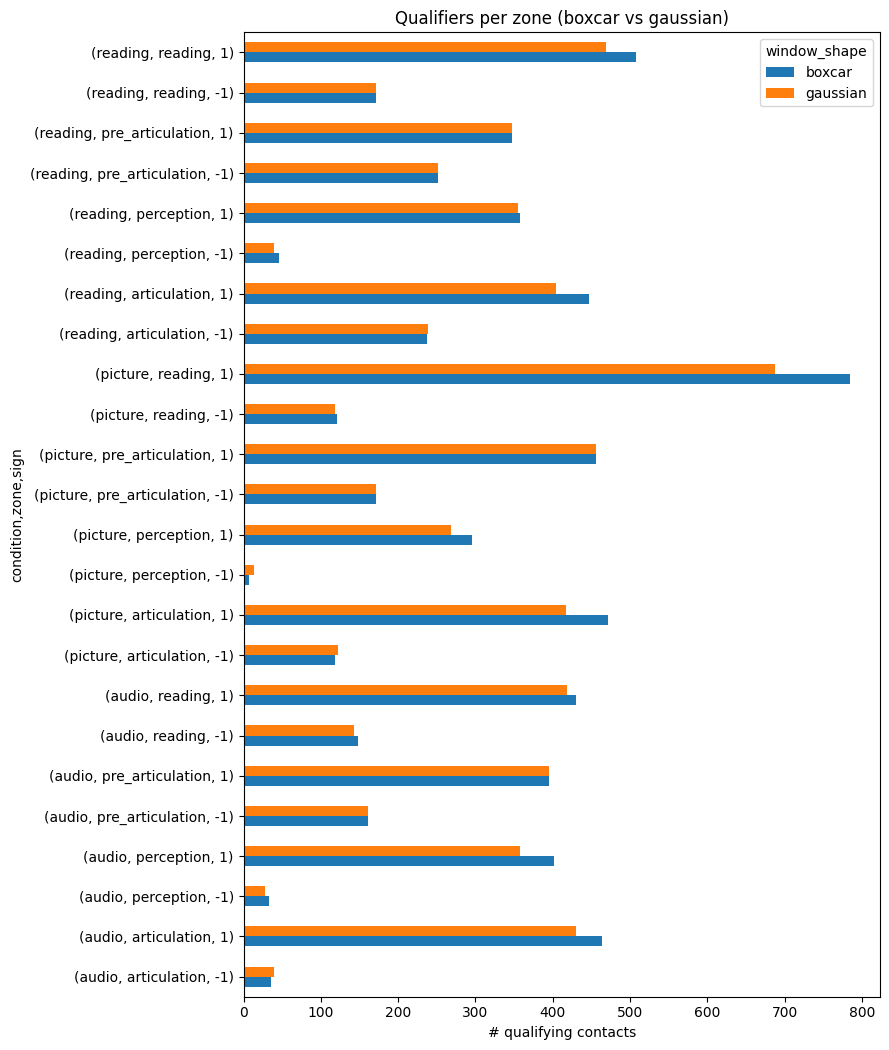

In [12]:
summ = P.qualifier_summary(df_pool)
display(summ)

import matplotlib.pyplot as plt
piv = summ.pivot_table(index=['condition', 'zone', 'sign'],
                       columns='window_shape', values='n_contacts', fill_value=0)
ax = piv.plot.barh(figsize=(9, 0.4 * len(piv) + 1))
ax.set_xlabel('# qualifying contacts'); ax.set_title('Qualifiers per zone (boxcar vs gaussian)')
plt.tight_layout(); plt.show()
